<a href="https://colab.research.google.com/github/sanusahana678-star/HomeLoan/blob/main/heart_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🫀 HEART DISEASE PREDICTION

### 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC


### 2. Load Dataset

In [ ]:
values = pd.read_csv("values.csv")
labels = pd.read_csv("labels.csv")

df = values.merge(labels, on="patient_id")
df.head()


,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


### 3. Basic Data Understanding

In [ ]:
df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


In [ ]:
df.isnull().sum()


,0
patient_id,0
slope_of_peak_exercise_st_segment,0
thal,0
resting_blood_pressure,0
chest_pain_type,0
num_major_vessels,0
fasting_blood_sugar_gt_120_mg_per_dl,0
resting_ekg_results,0
serum_cholesterol_mg_per_dl,0
oldpeak_eq_st_depression,0


In [ ]:
df.duplicated().sum()


np.int64(0)

### 4. Target Distribution (Check Balance)

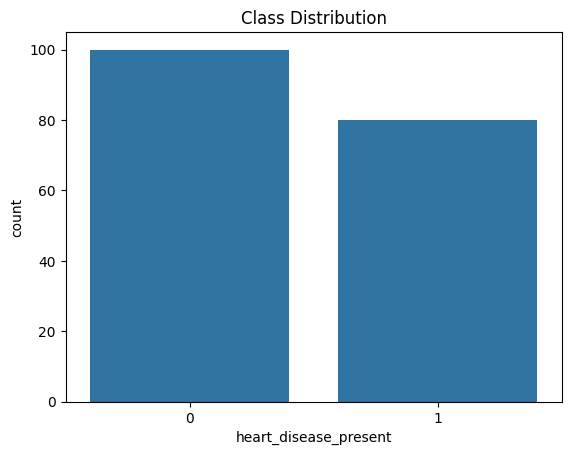

In [ ]:
df['heart_disease_present'].value_counts()
df['heart_disease_present'].value_counts(normalize=True)*100

sns.countplot(x='heart_disease_present', data=df)
plt.title("Class Distribution")
plt.show()


### 5.Correlation Heatmap

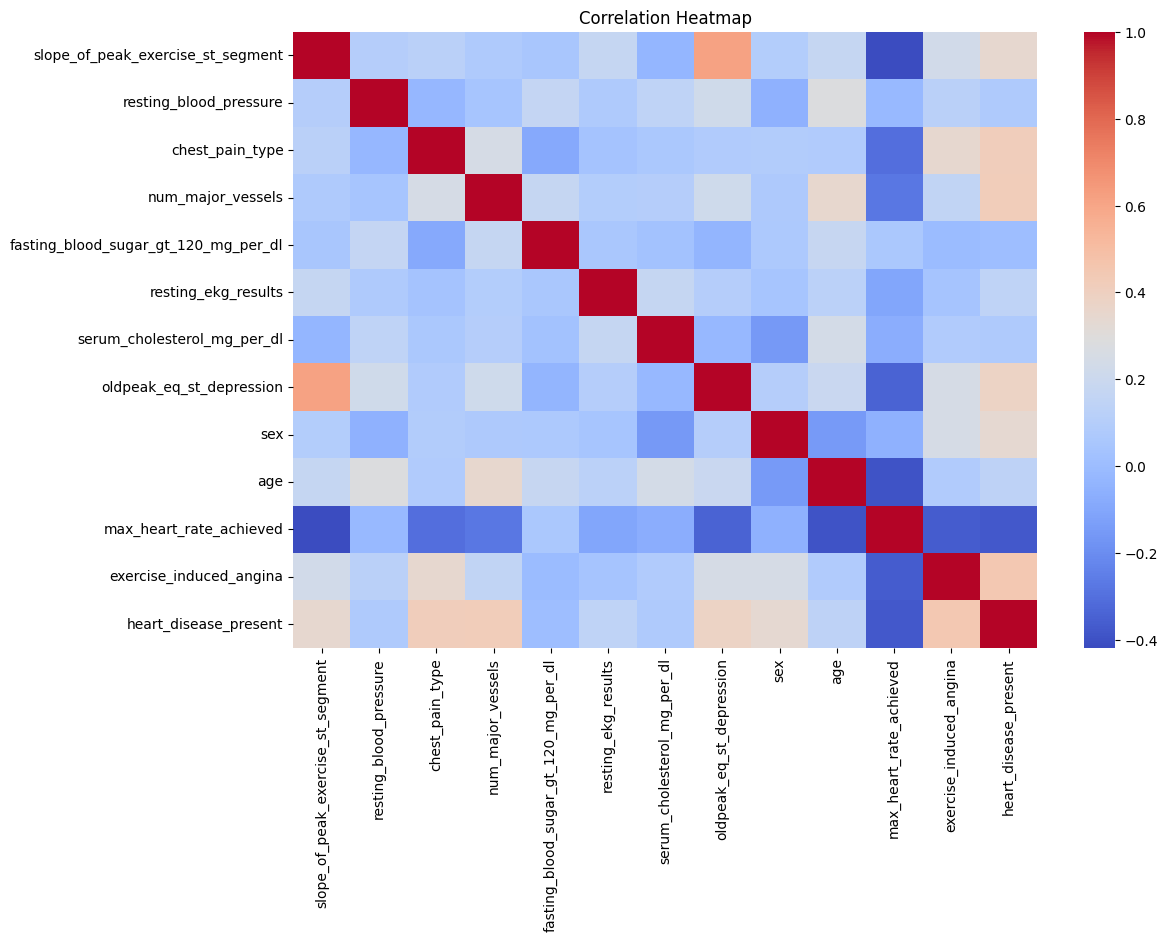

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


### 6. Important EDA Plots

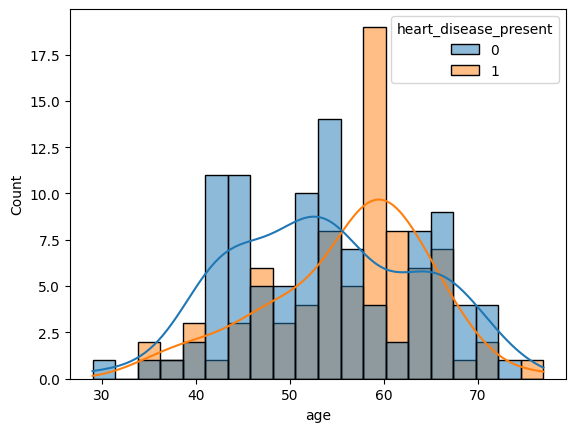

In [ ]:
#Age vs Disease
sns.histplot(data=df, x="age", hue="heart_disease_present", bins=20, kde=True)
plt.show()


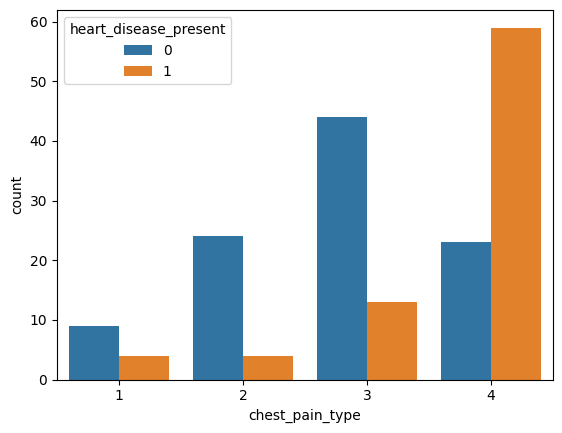

In [ ]:
#Chest Pain vs Disease
sns.countplot(x="chest_pain_type", hue="heart_disease_present", data=df)
plt.show()


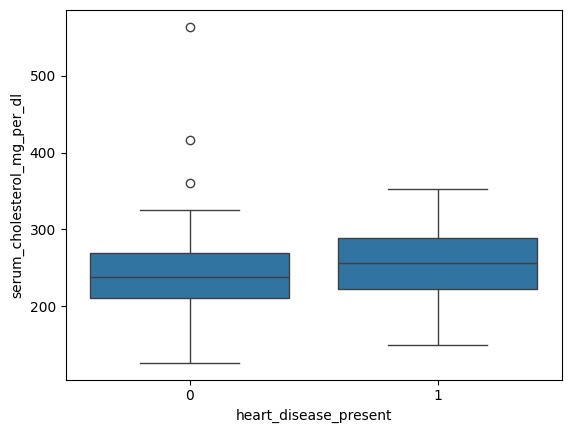

In [ ]:
#Cholesterol vs Disease
sns.boxplot(x="heart_disease_present", y="serum_cholesterol_mg_per_dl", data=df)
plt.show()


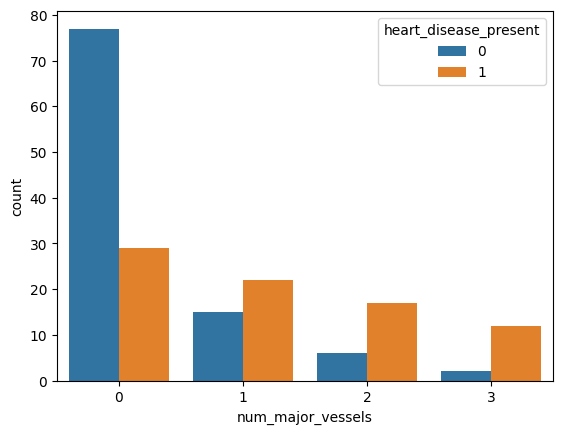

In [ ]:
#Blocked Vessels vs Disease
sns.countplot(x="num_major_vessels", hue="heart_disease_present", data=df)
plt.show()


### 7. Preprocessing (Encoding)

In [ ]:

cat_cols = ['thal','chest_pain_type','resting_ekg_results','slope_of_peak_exercise_st_segment']

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))


### 8. Split Features & Target

In [ ]:
X = df.drop(['heart_disease_present','patient_id'], axis=1)
y = df['heart_disease_present']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


### 9. Scaling

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


### 10. Train All Models & Compare

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(probability=True),
    'Gradient Boosting': GradientBoostingClassifier()
}

results = []
trained_models = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)

    results.append([name, acc, prec, rec, f1, auc])
    trained_models[name] = model

results_df = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1","ROC_AUC"])
results_df.sort_values(by="Recall", ascending=False)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
3,Random Forest,0.944444,0.888889,1.0000,0.941176,0.954688
5,Gradient Boosting,0.833333,0.750000,0.9375,0.833333,0.931250
1,KNN,0.861111,0.823529,0.8750,0.848485,0.921875
0,Logistic Regression,0.833333,0.777778,0.8750,0.823529,0.937500
4,SVM,0.805556,0.736842,0.8750,0.800000,0.946875
2,Decision Tree,0.722222,0.650000,0.8125,0.722222,0.731250


### 11. Select Best Model (Healthcare Rule)


In [ ]:
best_row = results_df.sort_values(by=["Recall","ROC_AUC","F1"], ascending=False).iloc[0]
best_model_name = best_row["Model"]

print("Best Model:", best_model_name)
best_model = trained_models[best_model_name]


Best Model: Random Forest


### 12. Final Evaluation

In [ ]:
final_preds = best_model.predict(X_test)
final_probs = best_model.predict_proba(X_test)[:,1]

print(confusion_matrix(y_test, final_preds))
print(classification_report(y_test, final_preds))
print("ROC-AUC:", roc_auc_score(y_test, final_probs))


[[18  2]
 [ 0 16]]
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        20
           1       0.89      1.00      0.94        16

    accuracy                           0.94        36
   macro avg       0.94      0.95      0.94        36
weighted avg       0.95      0.94      0.94        36

ROC-AUC: 0.9546875


### 13. ROC Curve

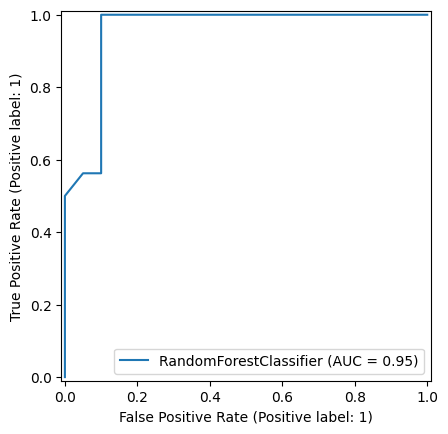

In [ ]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.show()


### 14. Feature Importance (Explainable AI)

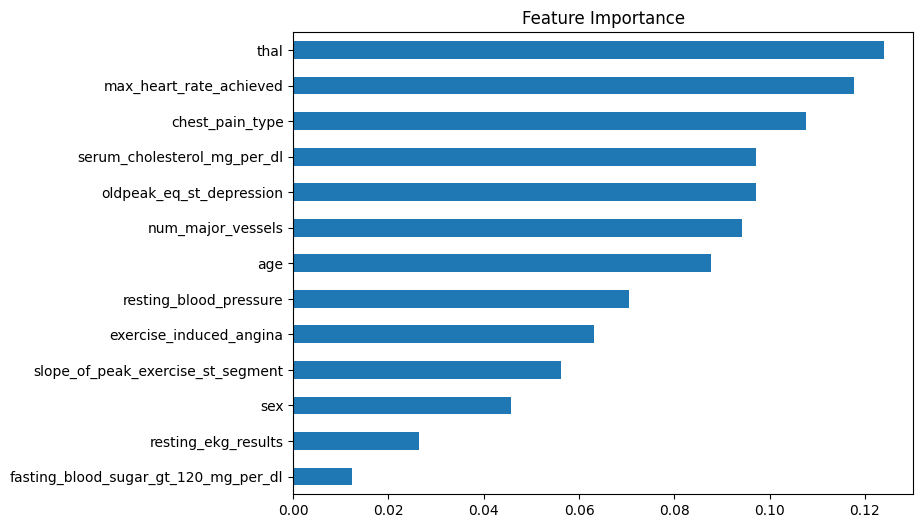

In [ ]:
if best_model_name == "Random Forest":
    importance = pd.Series(best_model.feature_importances_, index=X.columns)
    importance.sort_values().plot(kind='barh', figsize=(8,6))
    plt.title("Feature Importance")
    plt.show()


### 15.Save Final Model

In [ ]:
import joblib
joblib.dump(best_model, "final_heart_disease_model.pkl")


['final_heart_disease_model.pkl']

### 📄 CONCLUSION


The objective of predicting heart disease using machine learning techniques was successfully achieved. Among all tested algorithms, the Random Forest classifier produced the most reliable results with high recall and ROC-AUC score, making it suitable for medical screening applications.

The model correctly identified most patients at risk while maintaining balanced precision, reducing the probability of missing diseased patients. This demonstrates that machine learning can effectively assist healthcare professionals in early diagnosis and preventive treatment planning.

The developed system can be used as a decision-support tool to help doctors prioritize high-risk patients for further medical examination, thereby improving patient outcomes and reducing mortality risk.

### 🌟 FUTURE SCOPE

The project can be extended by:

- Using larger real hospital datasets

- Integrating real-time patient monitoring systems

- Deploying a web application for hospital use

- Applying deep learning models for improved accuracy

- Incorporating lifestyle and genetic factors
